In [1]:
! pip install pandas matplotlib yfinance


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
def plot_timeseries(df, stock_name=""):
    plt.figure()
    df["Close"].plot(style='r', label="closing")
    df['close_ewma'].plot(style='b-.', label="EWMA")
    plt.legend(fontsize=15)
    plt.ylabel("stock prize", fontsize=15)
    plt.title(stock_name, fontsize=15)

In [4]:
st_MSFT = yf.Ticker("MSFT")

get all key value pairs that are available

In [5]:
for key, value in st_MSFT.info.items():
    print(key, ": ", value)

address1 :  One Microsoft Way
city :  Redmond
state :  WA
zip :  98052-6399
country :  United States
phone :  425 882 8080
website :  https://www.microsoft.com
industry :  Software - Infrastructure
industryKey :  software-infrastructure
industryDisp :  Software - Infrastructure
sector :  Technology
sectorKey :  technology
sectorDisp :  Technology
longBusinessSummary :  Microsoft Corporation develops and supports software, services, devices, and solutions worldwide. The Productivity and Business Processes segment offers Microsoft 365 commercial, enterprise mobility + security, windows commercial, power BI, exchange, sharepoint, Microsoft teams, security and compliance, and copilot; Microsoft 365 commercial products, such as Windows commercial on-premises and office licensed services; Microsoft 365 consumer products and cloud services, including Microsoft 365 consumer subscriptions, office licensed on-premises, and other consumer services; LinkedIn; dynamics products and cloud services, 

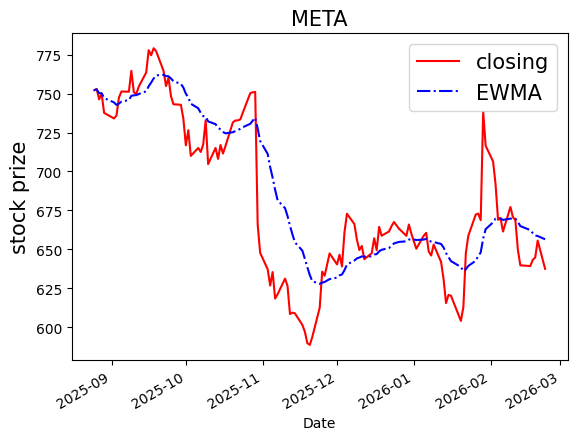

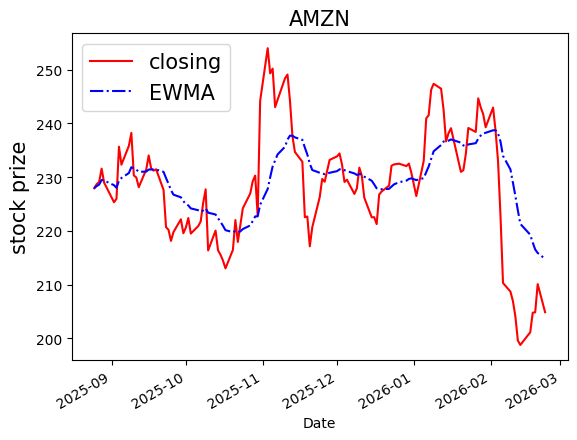

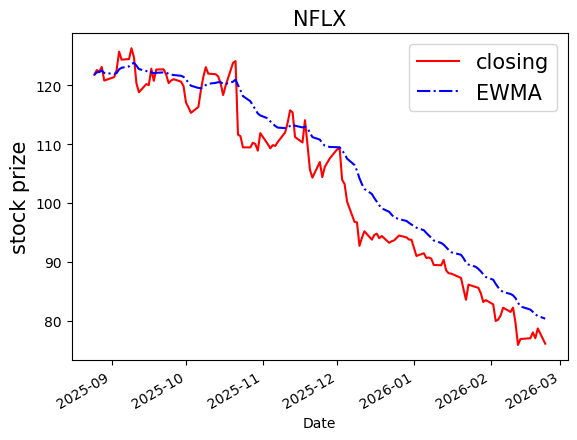

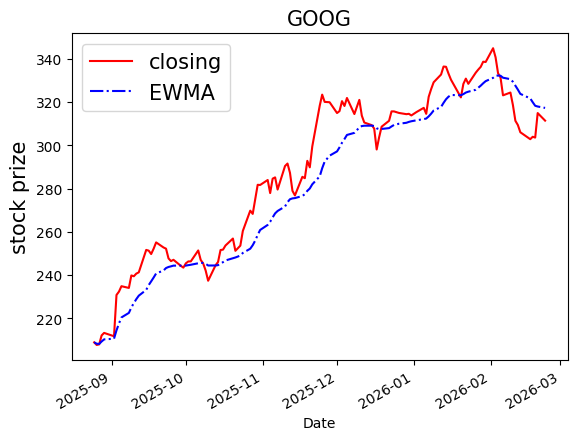

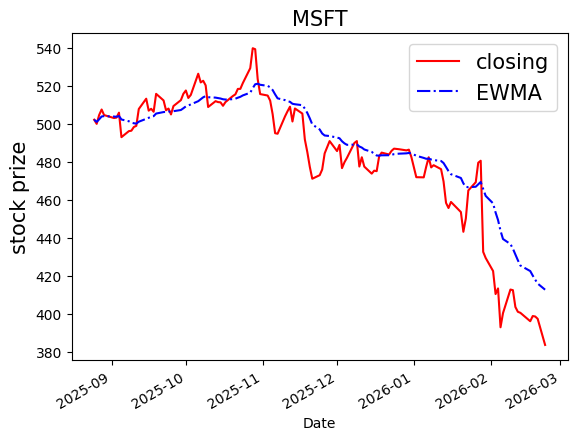

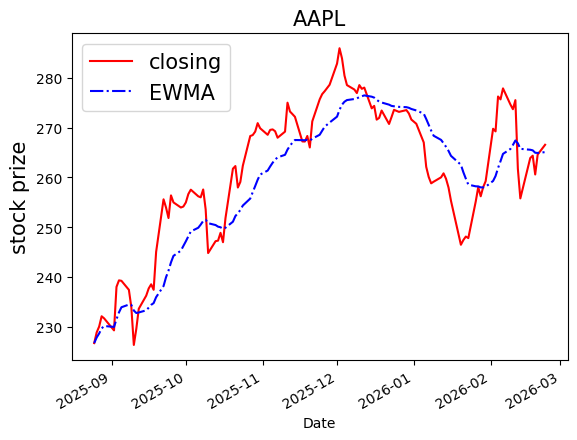

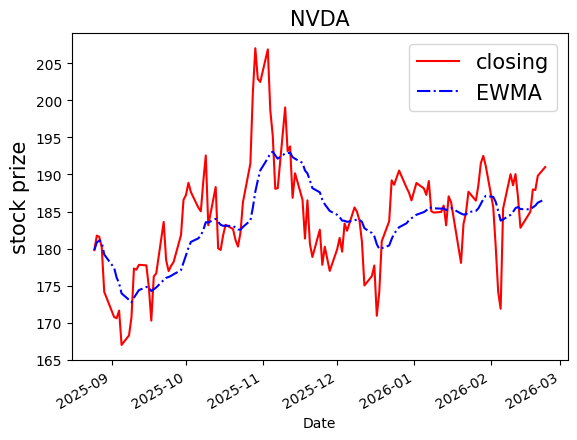

In [6]:
stock_list = []
# FANGMAN
for stock in ["META", "AMZN", "NFLX", "GOOG", "MSFT", "AAPL", "NVDA"]:
    df = yf.Ticker(stock).history(period="6mo")
    df["close_ewma"] = df["Close"].ewm(alpha=0.1, ignore_na=True).mean()
    plot_timeseries(df, stock)
    stock_list.append(df)

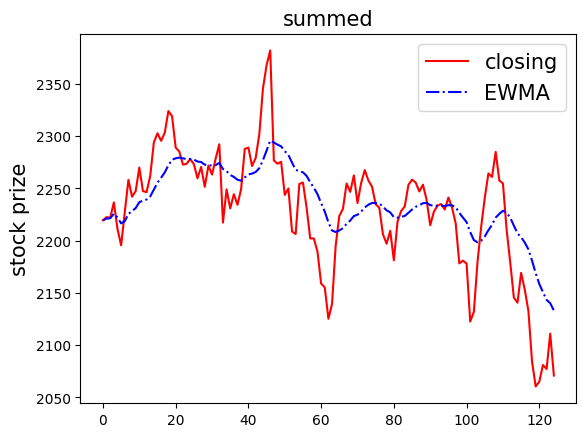

In [7]:
df = pd.concat(stock_list)
df_summed = df.groupby(['Date'])[['Close', 'close_ewma']].sum().reset_index()
plot_timeseries(df_summed, "summed")